# Population geometry of fixation type in four social-brain areas

*Main chapter: Introduction · Methods · Results · Discussion, followed by an
appendix on the population subspaces.*

Five figures carry the results. They are sized and ordered to be stitched into a
single composite figure for the paper.

| Figure | Question it answers |
|---|---|
| 1 | What kind of signal distinguishes the three fixation types? |
| 2 | How many population dimensions does the analysis need? |
| 3 | What do the population trajectories look like? |
| 4 | Which population axis carries which distinction? |
| 5 | Do the conditions *move together*, and which ones? |

Appendix figures A1–A4 give the subspace analyses: cross-condition variance
explained, principal angles, and the summary statistics.

Regenerate with
`conda run -n gaze_processing python notebooks/population_thesis/_build_main_chapter.py`.
The long-form version, with every verification and control, is
`population_geometry_chapter.ipynb`.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_population_pc_subspace as pcs
from dal_monte_2022_analysis.ephys.plotting import fixation_population_pc_subspace as viz
from dal_monte_2022_analysis.ephys.plotting import thesis_common as style

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
PLOTTING_CFG_PATH = repo_root / "configs" / "plotting.yaml"
style.apply_thesis_plot_style(load_config(PLOTTING_CFG_PATH))
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

WINDOW_MS = (-500.0, 500.0)
VARIANCE_THRESHOLD = 0.95
N_BOOTSTRAP = 400          # neuron resamples for variance shares and PC separation
N_SUBSAMPLES = 200         # neuron subsamples for the subspace metrics
RANDOM_SEED = 20260827
EXAMPLE_REGION = "bla"

FIGURE_DIR = pcs.resolve_output_dir(DATASET_CFG_PATH, scope="main_chapter")
FIGURE_MANIFEST: dict[str, Path] = {}
PAIR_SHORT = {
    "face_interactive__vs__face_non_interactive": "IF/NF",
    "face_interactive__vs__object": "IF/OB",
    "face_non_interactive__vs__object": "NF/OB",
}


def figure(fig, stem: str, caption: str, *, dpi: int = 220) -> None:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    for extension in ("pdf", "png"):
        path = FIGURE_DIR / f"{stem}.{extension}"
        fig.savefig(path, dpi=dpi if extension == "png" else None, bbox_inches="tight", transparent=False)
        FIGURE_MANIFEST[f"{stem}.{extension}"] = path
    display(Image(filename=str(FIGURE_DIR / f"{stem}.png")))
    display(Markdown(caption))
    import matplotlib.pyplot as plt

    plt.close(fig)


def table(frame: pd.DataFrame, stem: str) -> pd.DataFrame:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURE_DIR / f"{stem}.csv"
    frame.to_csv(path, index=False)
    FIGURE_MANIFEST[f"{stem}.csv"] = path
    return frame


def lines(items) -> None:
    display(Markdown(chr(10).join(items)))


populations = pcs.load_region_populations(DATASET_CFG_PATH, window_ms=WINDOW_MS)
fits = {region: pcs.fit_all_scopes(population) for region, population in populations.items()}
K, per_region_components = pcs.resolve_shared_n_components(fits, threshold=VARIANCE_THRESHOLD)
inventory = table(pcs.build_unit_inventory(populations), "t01_inventory")
print("outputs:", FIGURE_DIR)
print("units:", int(inventory["n_units"].sum()), "| retained components:", K)

outputs: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_population_pc_subspace/main_chapter
units: 1201 | retained components: 42


---

## 1. Introduction

In the dyadic task a monkey's gaze lands on three kinds of target: the partner's
**face during an interactive period**, the **same face during a non-interactive
period**, and a neutral **object**. The three differ along two axes at once —
what is being looked at, and whether a social exchange is underway — so the
interesting comparison is not simply face versus object, but whether interactive
context changes how a face is represented.

Single-unit selectivity already tells us the information is present: a
substantial minority of cells in each area distinguishes at least one pair. It
does not tell us how that information is arranged. A population can carry three
distinguishable signals in several ways, with different implications:

- The three could sit at **different levels along a shared axis** — one
  "salience" dimension, faces above objects.
- They could occupy **different subspaces** — different combinations of neurons
  active for each.
- They could share a subspace but **traverse it differently in time** — the same
  repertoire of states, visited in a different order or at different moments.

Counting selective neurons cannot separate these. They are questions about
geometry, and they need population-level measures.

**What a subspace means here.** With $N$ recorded neurons, the population state
at any instant is $N$ numbers, i.e. a point in an $N$-dimensional space. Over the
second surrounding a fixation that point traces a trajectory. Neurons are
correlated, so the trajectory does not fill the space — it is confined to a
low-dimensional **subspace**, which describes the patterns of coordinated
activity the population actually produces.

**This chapter finds** that all three conditions occupy clearly separated states
in BLA, ACCg, dmPFC and OFC; that the separation is overwhelmingly a **static
offset** rather than differing dynamics; that individual population axes carry
specific distinctions (in three of four areas, one axis codes face-versus-object
and another codes interactive-versus-non-interactive); and that the two face
conditions **move through their own neighbourhoods at the same moments**, which
face and object do not. dmPFC departs from the pattern throughout.

---

## 2. Methods

Presented in the order the results use them.

### 2.1 Data

Trial-averaged peri-fixation firing rates, 10 ms bins, from the combined 10 ms
average export. Per-trial rates are Gaussian-smoothed at $\sigma = 20$ ms before
averaging, so adjacent bins are not independent — this matters in §2.6. Values
are in Hz.

Window: $[-500, +500]$ ms around fixation onset, $T = 100$ bins. A unit enters
only if it has an average for all three conditions, since every comparison needs
the same neurons in every condition.

Interactive and non-interactive face come from the interactive-state–split
averages; object comes from the **unsplit** average, pooling object fixations
across interactive state because there are too few per state to average. Object
is therefore not matched for interactive state — see §5.3.

Interactive-face fixations outnumber the other two roughly **five to one**
(median ~850 versus ~168 per unit). A mean built from more trials is quieter, and
a quieter average looks like a population that varies less, so any statement
about how much a condition varies must be corrected for this. Each stored average
carries a standard error $s_c(t,n)$, from which the expected noise energy is
computed and subtracted wherever it matters.

### 2.2 Splitting the response into three parts

**In words.** Take one neuron. It has three curves, one per condition, each 100
points long. They are firing rates, so non-negative. First set aside the
neuron's **baseline**: its overall mean across all conditions and times, one
number. Everything below describes departures from that baseline, so the parts
are centred on zero even though the rates are not.

Then ask three questions.

1. *Does the neuron respond to fixating at all, regardless of target?* Average
   the three curves point by point. What survives is the **shared time course**.
2. *Do the three curves sit at different heights?* Take each curve's own average
   level — one number per condition. If those differ, the neuron fires at
   different rates for different fixation types, steadily across the window. This
   is the **condition offset**, i.e. the condition's centroid.
3. *Is anything left?* Subtract the shared time course and the condition's own
   level from each curve. The remainder is a bump one condition has and the
   others do not: the **condition × time** term.

Baseline plus these three reproduces the original curves exactly.

**In symbols.** With $r_{ctn}$ the rate for condition $c$, bin $t$, neuron $n$,
and a dot denoting an average over that index:

$$
\underbrace{\bar r_{\cdot\cdot n}}_{\text{baseline}} \quad
\underbrace{a_{tn} = \bar r_{\cdot t n} - \bar r_{\cdot\cdot n}}_{\text{shared time course}} \quad
\underbrace{b_{cn} = \bar r_{c \cdot n} - \bar r_{\cdot\cdot n}}_{\text{condition offset}} \quad
\underbrace{e_{ctn} = r_{ctn} - \bar r_{\cdot\cdot n} - a_{tn} - b_{cn}}_{\text{condition} \times \text{time}}
$$

Each part is built by averaging over a different index, which makes it
uncorrelated with the others. Uncorrelated parts have additive squared sizes:

$$\sum_{c,t,n}\!\left(r_{ctn}-\bar r_{\cdot\cdot n}\right)^2
= C\!\sum_{t,n} a_{tn}^2 \;+\; T\!\sum_{c,n} b_{cn}^2 \;+\; \sum_{c,t,n} e_{ctn}^2$$

so each part can be quoted as a **share of the total**, and the three shares sum
to 1. This is the standard two-way ANOVA decomposition; **no PCA is involved**,
and no dimensionality choice affects it.

Shares are computed by summing squares across neurons **before** normalising, so
they describe the population trajectory rather than the average neuron.
Uncertainty comes from resampling neurons with replacement.

**Noise correction.** Estimation noise is independent across conditions and rough
in time, so nearly all of it lands in the $e_{ctn}$ term — exactly the one that
would otherwise be read as condition-specific dynamics. Writing $g_c$ for a
condition's total noise energy and $h_c$ for the part surviving a time average,
the expected noise in each part is

$$\text{shared} = \tfrac{1}{C}\sum_c (g_c - h_c), \quad
\text{offset} = \left(1-\tfrac{1}{C}\right)\sum_c h_c, \quad
\text{residual} = \left(1-\tfrac{1}{C}\right)\sum_c (g_c - h_c)$$

and is subtracted before normalising. $h_c$ uses the smoothing kernel's
autocorrelation, $\rho(\ell) = \exp(-\ell^2/4\sigma^2)$ with $\sigma = 2$ bins,
rather than assuming independent bins.

### 2.3 Projecting the population into components

**In words.** To see the three conditions as trajectories we need axes shared by
all of them. Lay the three condition matrices side by side along time, and find
the weighted combinations of neurons that vary the most across the resulting
snapshots. Each such combination is one **axis in neuron space**; projecting a
condition onto them gives its trajectory.

**In symbols.** With $X_c \in \mathbb{R}^{N\times T}$ the units-by-time matrix
for condition $c$, form
$X = [\,X_{\mathrm{IF}}\;X_{\mathrm{NF}}\;X_{\mathrm{OB}}\,] \in \mathbb{R}^{N\times 3T}$,
let $Y = X^{\top}$, subtract the mean over all $3T$ rows and take the SVD:

$$\mu = \tfrac{1}{3T}\textstyle\sum_s Y_{s\cdot}, \qquad
Y - \mathbf{1}\mu^{\top} = U\Sigma V^{\top}, \qquad W = V_{:,1:k}^{\top}$$

with $WW^{\top} = I_k$. The trajectory of condition $c$ is
$Z_c = W(X_c - \mu\mathbf{1}^{\top}) \in \mathbb{R}^{k\times T}$.

**Which mean is removed decides what the analysis can see.** Fitting on the
concatenated matrix centres on the grand mean, so each condition keeps its offset
— this is what makes the trajectories appear as separated clouds. Fitting a
single condition centres on *that condition's own* mean, so the offset is gone
before the axes exist. Positional measures use the concatenated fit; the
appendix's subspace measures use per-condition fits and are already blind to the
offsets.

### 2.4 Choosing the number of components

Pictures use three components because a page is two-dimensional; every number
uses more, because three capture only about half the variance. The retained count
is the smallest $k$ reaching 95% cumulative variance in the region that needs the
most:

$$k = \max_R \min\left\{k : \tfrac{\sum_{j\le k}\lambda_j}{\sum_j \lambda_j} \ge 0.95\right\}$$

Taking the maximum rather than the mean guarantees no region is analysed in a
space too small for it.

### 2.5 What each axis separates

**In words.** A component is one axis in neuron space. Asking what it encodes
means asking which pair of conditions it pulls furthest apart. For component $j$
and conditions $a, b$, take the two score time courses, subtract them, and average
the absolute difference over time. The absolute value makes it immune to a
component's arbitrary sign.

$$D_j(a,b) = \big\langle \,\lvert Z_a[j,t] - Z_b[j,t]\rvert\, \big\rangle_t$$

**Uncertainty.** Neurons are resampled with replacement while the **axes are held
fixed**: each resampled score is the same weighted sum of firing rates, taken over
the sampled neurons and renormalised. Refitting the PCA on each resample would be
the obvious choice and is wrong here — components with similar variance rotate
into one another between resamples, so "PC1" would not name the same axis twice.
Time bins are not a valid resampling unit either, since a smoothed trajectory's
bins are heavily autocorrelated.

Contrasts between pairs within a region and component use two-sided bootstrap
p-values, FDR-corrected across all 36 contrasts.

### 2.6 Do the conditions move together?

This is the measure the chapter turns on, so it is worth being explicit.

**The intuition.** Picture two dancers in a room. *Subspace overlap* asks whether
they know the same moves — whether they use the same directions at all. *Co-movement*
asks whether they are dancing **in sync**: when one leans left, does the other
lean left at that moment? A pair can score high on one and zero on the other.
Sharing a repertoire but visiting it at unrelated times means a common capacity;
moving together means a common, time-locked process.

**The computation.**

1. Take each condition's trajectory $Z_c(t)$ in the shared component space.
2. Compute its **centroid** $m_c = \frac{1}{T}\sum_t Z_c(t)$ — its average
   position, the offset of §2.2 written as a vector.
3. Subtract it: $d_c(t) = Z_c(t) - m_c$. Each condition is now a wiggle about its
   own centre. **Nothing below can be driven by the offsets.**
4. At each bin take the **dot product** $d_a(t)^{\top}d_b(t)$: positive when the
   two are displaced the same way at that moment, negative when opposite.
5. Average over time and normalise:

$$\rho_{ab} = \frac{\big\langle d_a(t)^{\top} d_b(t)\big\rangle_t}
{\sqrt{\big\langle\lVert d_a\rVert^2\big\rangle_t \big\langle\lVert d_b\rVert^2\big\rangle_t}} \in [-1, 1]$$

An ordinary correlation coefficient, except the things correlated are vectors
moving in $k$ dimensions rather than scalars. $\rho = 1$ means the two trace the
same excursion at the same time; $\rho = 0$ means they move independently.

**Why it needs its own null.** Both trajectories are smooth, and **two smooth
curves correlate substantially by accident**. Comparing $\rho$ to zero would be
far too permissive. The null therefore **circularly shifts** one condition's
wiggle relative to the other: each keeps its own shape, smoothness and size, and
only the claim "these happen at the same moment" is destroyed. All 81 admissible
shifts are used (shifts under 10 bins overlap themselves), so the test is exact;
the smallest attainable $p$ is $1/82 = 0.012$.

**Disattenuation.** Estimation noise inflates the denominator but not the
numerator, since noise is independent across conditions. The reported $\rho$
divides by the noise-corrected excursion energies instead. This is a single
positive multiplier applied to observed and null alike, so no p-value changes —
but the null band must be rescaled with it, or a large bar will appear to clear a
band it does not.

---

## 3. Results

### 3.1 The conditions differ by a static offset, not by their dynamics

Figure 1 works the three-way split through on one neuron and then reports the
population statistic. Note the vertical scale shared by panels 2–4: for this cell
the constant per-condition displacement is far larger than either the shared
response or the condition-specific wiggle.

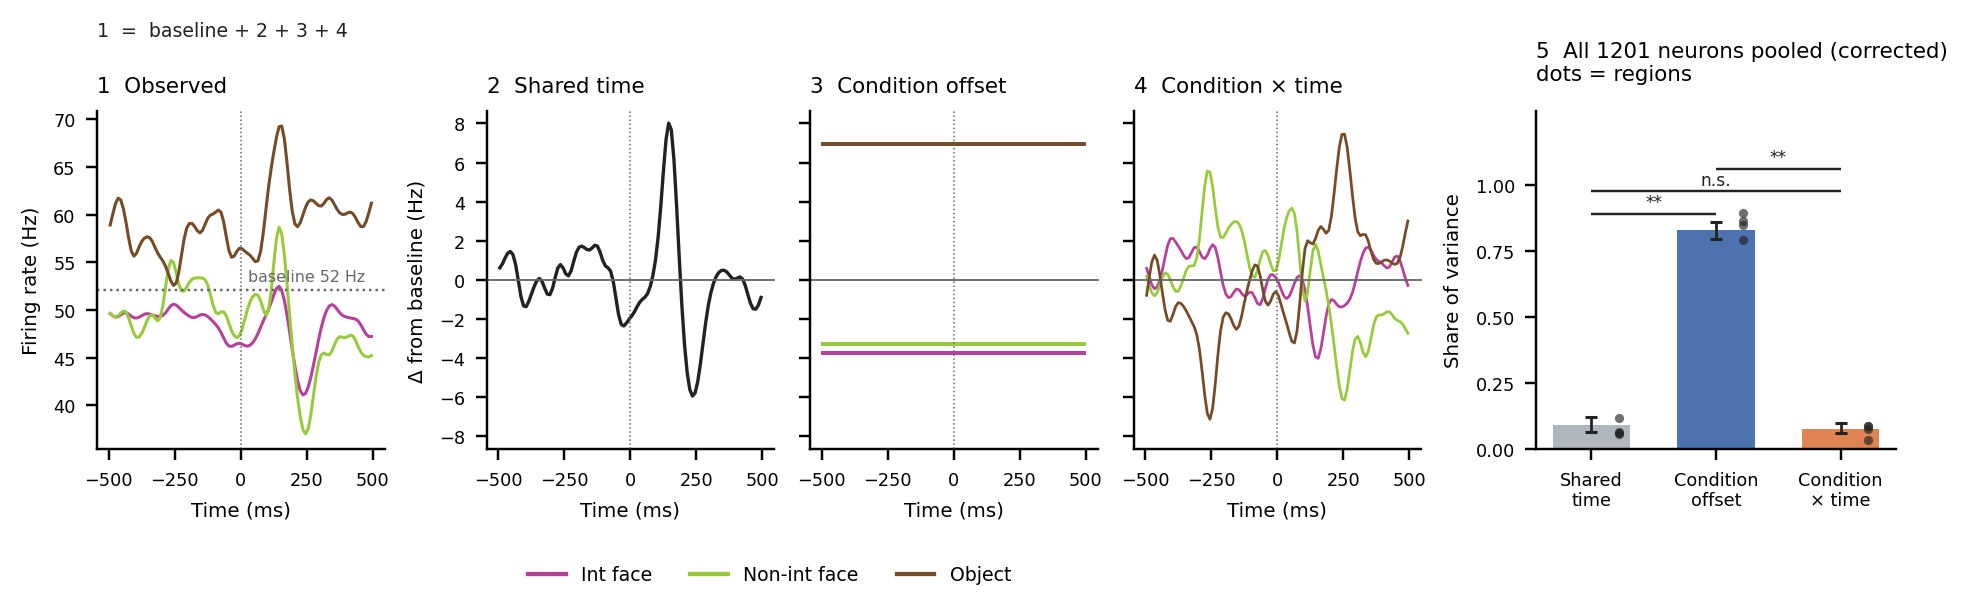

**Figure 1. The three fixation types differ mainly by a constant offset.** *1-4*: the split worked through on one neuron (`01092019|unit_uuid__2587`, BLA), in raw firing rate. Panel 1 is the observed data, non-negative and centred near the dotted baseline. Panels 2-4 are the three parts, each a **deviation from that baseline**, sharing one vertical scale so their sizes can be compared; baseline plus 2, 3 and 4 reproduces panel 1 exactly. *5*: the variance-weighted share of each part over all neurons pooled across regions, after subtracting the SEM-derived noise energy; bars are neuron-bootstrap 95% intervals, dots the four regions, brackets FDR-corrected contrasts. The condition offset carries the large majority of the reliable variance.

**Share of population variance (all regions pooled, 95% neuron-bootstrap intervals)**

| Part | Observed | Noise-corrected |
|---|---|---|
| Shared time course | 19.8% (18.2%-21.6%) | 9.1% (6.7%-12.2%) |
| Condition offset | 46.9% (43.4%-50.4%) | 83.1% (79.8%-86.3%) |
| Condition x time | 33.3% (30.8%-35.7%) | 7.8% (6.1%-9.8%) |

The offset exceeds the shared time course (p = 0.007) and the condition x time term (p = 0.007), and is the largest part under both normalisations. After noise correction the shared time course and the interaction do not differ from each other (p = 0.53).

In [2]:
share_summary, share_contrasts = pcs.build_variance_share_summary(
    populations, n_bootstrap=N_BOOTSTRAP, seed=RANDOM_SEED
)
table(share_summary, "t02_variance_shares")
table(share_contrasts, "t03_variance_share_contrasts")

example_population = populations[EXAMPLE_REGION]
example = pcs.single_unit_decomposition(
    example_population, pcs.select_decomposition_example_unit(example_population)
)
figure(
    viz.plot_decomposition_overview(example, share_summary, share_contrasts),
    "fig01_variance_decomposition",
    "**Figure 1. The three fixation types differ mainly by a constant offset.** "
    f"*1-4*: the split worked through on one neuron (`{example['unit_key']}`, "
    f"{style.region_label(EXAMPLE_REGION)}), in raw firing rate. Panel 1 is the observed data, "
    "non-negative and centred near the dotted baseline. Panels 2-4 are the three parts, each a "
    "**deviation from that baseline**, sharing one vertical scale so their sizes can be compared; "
    "baseline plus 2, 3 and 4 reproduces panel 1 exactly. *5*: the variance-weighted share of each "
    "part over all neurons pooled across regions, after subtracting the SEM-derived noise energy; "
    "bars are neuron-bootstrap 95% intervals, dots the four regions, brackets FDR-corrected "
    "contrasts. The condition offset carries the large majority of the reliable variance.",
)

pooled = share_summary[share_summary["scope"] == "all_regions"].set_index(["normalization", "component"])
contrast = share_contrasts[share_contrasts["scope"] == "all_regions"].set_index(
    ["normalization", "component_a", "component_b"]
)
lines([
    "**Share of population variance (all regions pooled, 95% neuron-bootstrap intervals)**",
    "",
    "| Part | Observed | Noise-corrected |",
    "|---|---|---|",
] + [
    f"| {pcs.COMPONENT_LABELS[component]} | "
    f"{pooled.loc[('raw', component), 'share']:.1%} "
    f"({pooled.loc[('raw', component), 'ci_low']:.1%}-{pooled.loc[('raw', component), 'ci_high']:.1%}) | "
    f"{pooled.loc[('corrected', component), 'share']:.1%} "
    f"({pooled.loc[('corrected', component), 'ci_low']:.1%}-{pooled.loc[('corrected', component), 'ci_high']:.1%}) |"
    for component in pcs.COMPONENT_ORDER
] + [
    "",
    f"The offset exceeds the shared time course "
    f"(p = {contrast.loc[('corrected', 'shared_time_course', 'condition_offset'), 'p_value_corrected']:.3f}) "
    f"and the condition x time term "
    f"(p = {contrast.loc[('corrected', 'condition_offset', 'condition_by_time'), 'p_value_corrected']:.3f}), "
    "and is the largest part under both normalisations. After noise correction the shared time "
    "course and the interaction do not differ from each other "
    f"(p = {contrast.loc[('corrected', 'shared_time_course', 'condition_by_time'), 'p_value_corrected']:.2f}).",
])

### 3.2 How many dimensions the analysis needs

Three components are enough to look at, not enough to measure with.

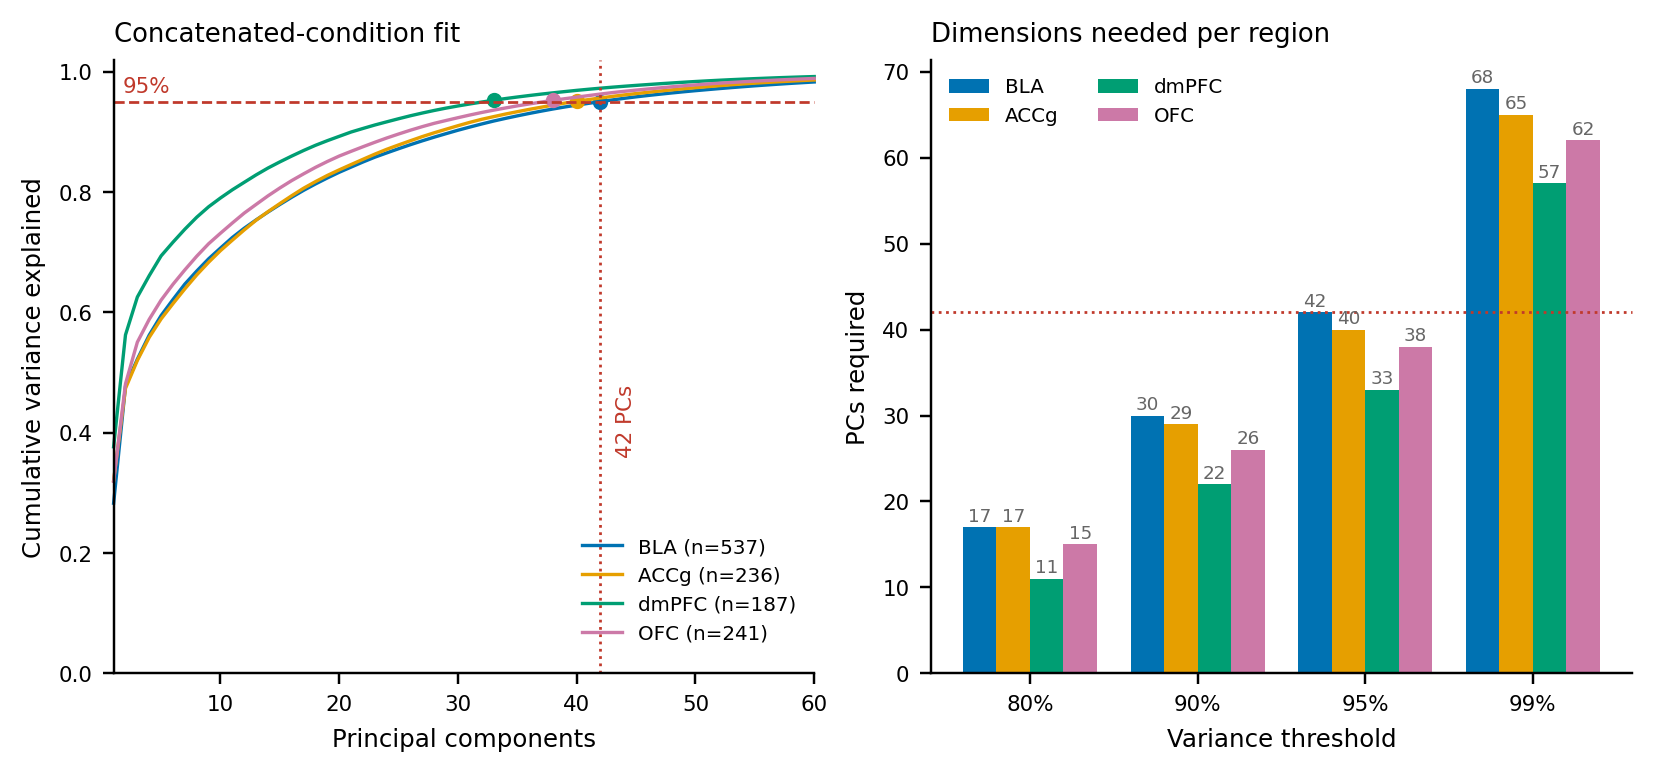

**Figure 2. Retained dimensions.** *Left*: cumulative variance of the concatenated fit; dots mark where each region reaches 95%. *Right*: components required at four thresholds; the dotted line is the shared retained count, set by the most demanding region. A handful of components carry most of the variance, but a long tail is needed to reach 95%.

**k = 42 components** reach 95% of the concatenated variance in every region (ACCg 40, BLA 42, dmPFC 33, OFC 38); BLA is binding.

Two caveats on that number. It comes from the **concatenated** fit, which spans three conditions' worth of structure; a single condition's own fit needs about half as many (median 20). And the participation ratio — an effective dimension count needing no threshold — is only ACCg 7.4, BLA 7.8, dmPFC 5.4, OFC 7.1. Most of the action is in a handful of dimensions; the rest of the 42 carry the 5% tail.

In [3]:
dimensionality = table(pcs.build_dimensionality_table(fits), "t04_dimensionality")
figure(
    viz.plot_cumulative_variance(fits, threshold=VARIANCE_THRESHOLD, shared_n_components=K),
    "fig02_dimensionality",
    "**Figure 2. Retained dimensions.** *Left*: cumulative variance of the concatenated fit; dots "
    "mark where each region reaches 95%. *Right*: components required at four thresholds; the "
    "dotted line is the shared retained count, set by the most demanding region. A handful of "
    "components carry most of the variance, but a long tail is needed to reach 95%.",
)
concatenated = dimensionality[dimensionality["fit_scope"] == "concatenated"].set_index("region")
per_condition = dimensionality[dimensionality["fit_scope"] != "concatenated"]
lines([
    f"**k = {K} components** reach {VARIANCE_THRESHOLD:.0%} of the concatenated variance in every "
    "region ("
    + ", ".join(f"{style.region_label(r)} {c}" for r, c in sorted(per_region_components.items()))
    + f"); {style.region_label(max(per_region_components, key=per_region_components.get))} is binding.",
    "",
    "Two caveats on that number. It comes from the **concatenated** fit, which spans three "
    "conditions' worth of structure; a single condition's own fit needs about half as many "
    f"(median {per_condition['n_pcs_for_95pct'].median():.0f}). And the participation ratio "
    f"— an effective dimension count needing no threshold — is only "
    + ", ".join(f"{style.region_label(r)} {concatenated.loc[r, 'participation_ratio']:.1f}" for r in sorted(concatenated.index))
    + ". Most of the action is in a handful of dimensions; the rest of the 42 carry the 5% tail.",
])

### 3.3 What the trajectories look like

All three conditions are drawn in the concatenated basis, so the axes mean the
same thing for every curve and the distances shown are real. Viewing angles are
searched per region, because the conditions separate along different component
combinations in each area and one fixed camera cannot serve all four.

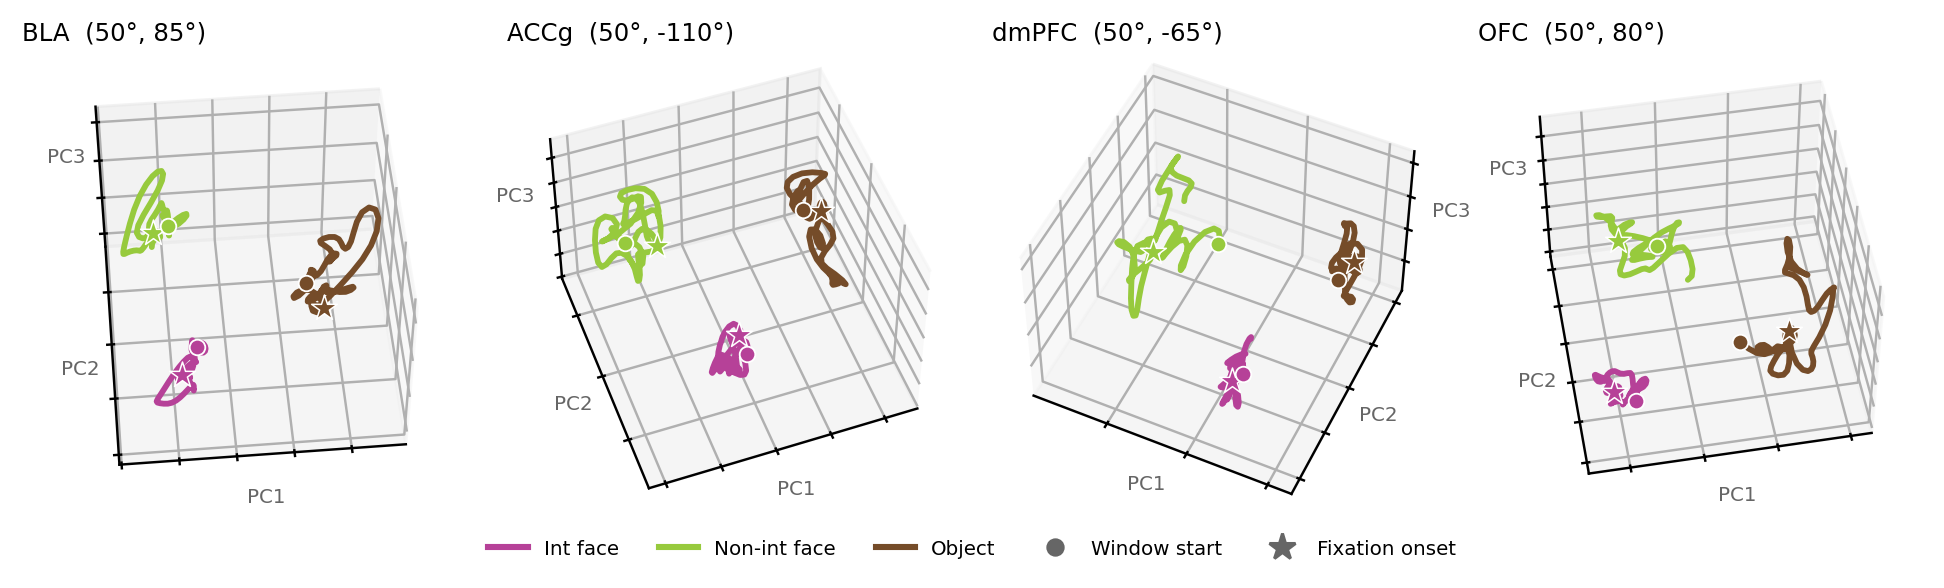

**Figure 3. Population trajectories in the top three components.** One panel per region, all three conditions in a shared coordinate system. Circle marks the start of the window, star marks fixation onset. Each panel's viewing angle is chosen by maximising the product of between-condition separation and within-trajectory unfolding, since optimising separation alone converges on a top-down view that collapses every trajectory. The three conditions form compact, well-separated clouds in every region, and each cloud is small relative to the distances between them - the geometric counterpart of Figure 1.

Viewing angles (elevation, azimuth): `bla` 50, 85, `accg` 50, -110, `dmpfc` 50, -65, `ofc` 50, 80

In [4]:
trajectory_figure, views = viz.plot_pc_trajectories_3d(fits)
figure(
    trajectory_figure,
    "fig03_trajectories_3d",
    "**Figure 3. Population trajectories in the top three components.** One panel per region, all "
    "three conditions in a shared coordinate system. Circle marks the start of the window, star "
    "marks fixation onset. Each panel's viewing angle is chosen by maximising the product of "
    "between-condition separation and within-trajectory unfolding, since optimising separation "
    "alone converges on a top-down view that collapses every trajectory. The three conditions form "
    "compact, well-separated clouds in every region, and each cloud is small relative to the "
    "distances between them - the geometric counterpart of Figure 1.",
)
display(Markdown(
    "Viewing angles (elevation, azimuth): "
    + ", ".join(f"`{r}` {a[0]:.0f}, {a[1]:.0f}" for r, a in views.items())
))

### 3.4 Individual axes carry specific distinctions

If the conditions were arranged along one "salience" axis, the same component
would separate every pair, in the same order. They are not. In three of the four
areas one component acts as a **face-versus-object** axis and a different one as
an **interactive-versus-non-interactive** axis.

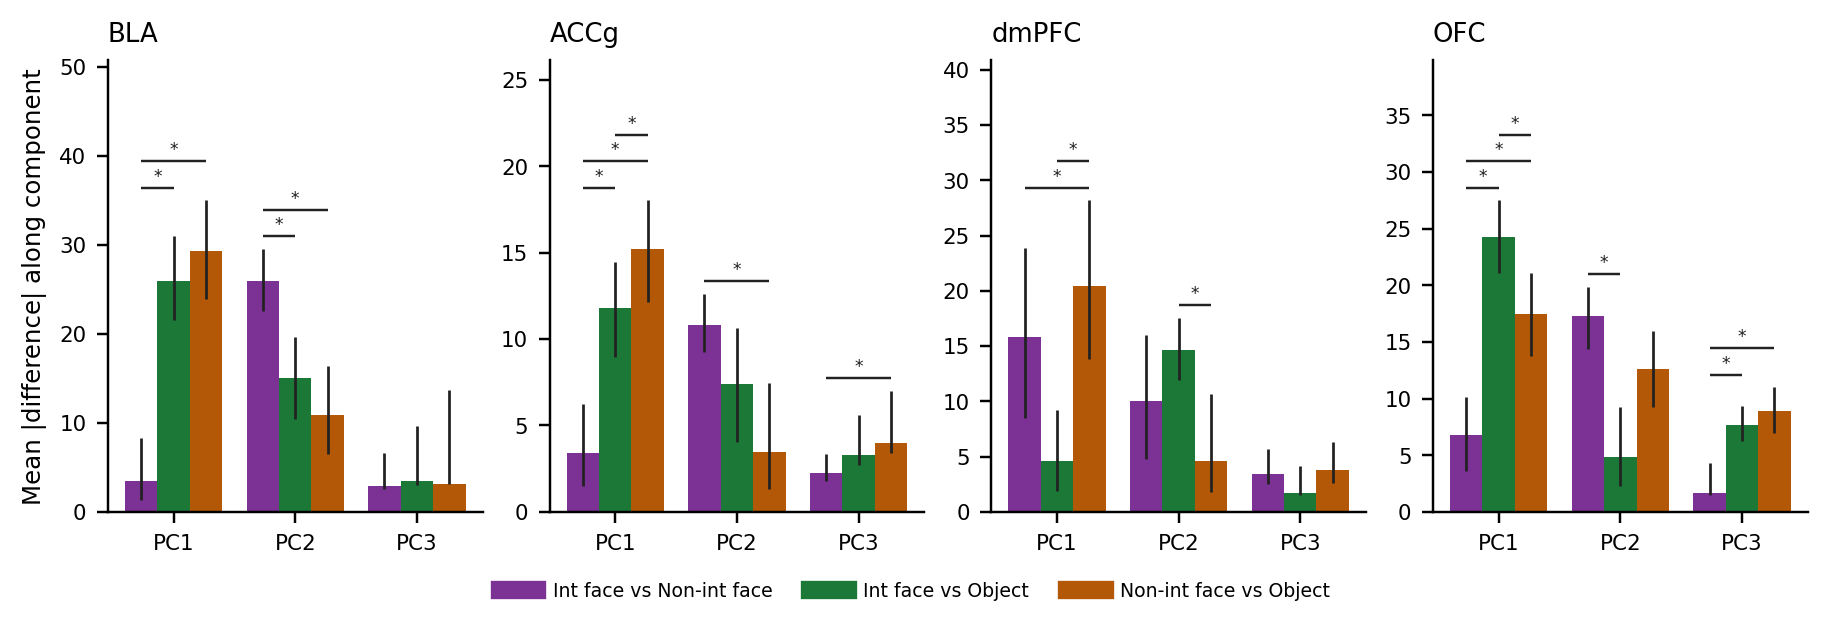

**Figure 4. Which axis carries which distinction.** Mean absolute difference between two conditions' score time courses along each of the first three components, with neuron-bootstrap 95% intervals; brackets are FDR-corrected contrasts between pairs (* p < 0.05). In BLA, ACCg and OFC, PC1 separates the two face conditions from object while barely separating them from each other, and PC2 does the reverse - two distinct coding axes rather than one graded one. dmPFC does not follow this arrangement.

- **ACCg PC1** separates `NF/OB` most (15.2) and `IF/NF` least (3.4).
- **ACCg PC2** separates `IF/NF` most (10.8) and `NF/OB` least (3.4).
- **BLA PC1** separates `NF/OB` most (29.4) and `IF/NF` least (3.5).
- **BLA PC2** separates `IF/NF` most (26.0) and `NF/OB` least (10.9).
- **dmPFC PC1** separates `NF/OB` most (20.5) and `IF/OB` least (4.6).
- **dmPFC PC2** separates `IF/OB` most (14.7) and `NF/OB` least (4.6).
- **OFC PC1** separates `IF/OB` most (24.2) and `IF/NF` least (6.8).
- **OFC PC2** separates `IF/NF` most (17.3) and `IF/OB` least (4.9).

18 of 36 pairwise contrasts survive FDR correction.

In [5]:
pc_effects, pc_contrasts = pcs.build_pc_condition_separation(
    populations, fits, n_pcs=3, n_bootstrap=N_BOOTSTRAP, seed=RANDOM_SEED
)
table(pc_effects, "t05_pc_separation")
table(pc_contrasts, "t06_pc_separation_contrasts")
figure(
    viz.plot_pc_condition_separation(pc_effects, pc_contrasts),
    "fig04_pc_condition_separation",
    "**Figure 4. Which axis carries which distinction.** Mean absolute difference between two "
    "conditions' score time courses along each of the first three components, with neuron-bootstrap "
    "95% intervals; brackets are FDR-corrected contrasts between pairs (* p < 0.05). In BLA, ACCg "
    "and OFC, PC1 separates the two face conditions from object while barely separating them from "
    "each other, and PC2 does the reverse - two distinct coding axes rather than one graded one. "
    "dmPFC does not follow this arrangement.",
)

summary = []
for region in sorted(populations):
    subset = pc_effects[pc_effects["region"] == region]
    for pc in (1, 2):
        row = subset[subset["pc_index"] == pc].sort_values("mean_abs_difference", ascending=False)
        summary.append(
            f"- **{style.region_label(region)} PC{pc}** separates "
            f"`{PAIR_SHORT[row['pair_label'].iloc[0]]}` most "
            f"({row['mean_abs_difference'].iloc[0]:.1f}) and "
            f"`{PAIR_SHORT[row['pair_label'].iloc[-1]]}` least "
            f"({row['mean_abs_difference'].iloc[-1]:.1f})."
        )
n_significant = int((pc_contrasts["p_value_corrected"] < 0.05).sum())
lines(summary + [
    "",
    f"{n_significant} of {len(pc_contrasts)} pairwise contrasts survive FDR correction.",
])

### 3.5 The two face conditions move together; face and object do not

The measures so far are positional. This one is not: the centroids are removed
first, so it asks only whether the conditions' *excursions* are locked to each
other in time.

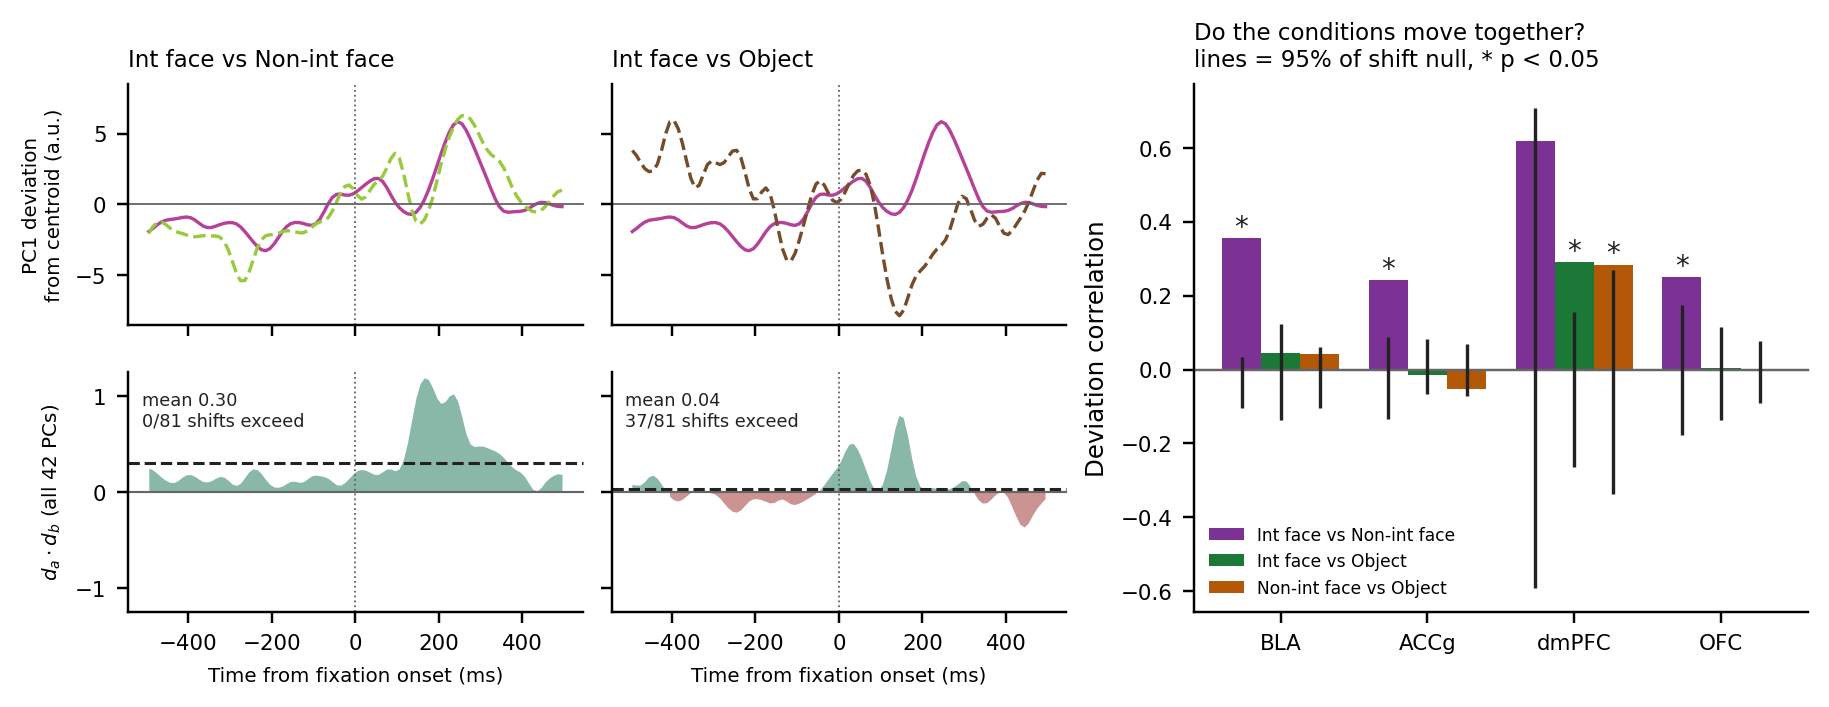

**Figure 5. Time-locked co-movement separates faces from objects.** *Left two columns*: the measure built on two example pairs in BLA. Top, each condition's trajectory after removing its own centroid, along the leading of the 42 components; the two panels share one axis so the pairs are directly comparable. The measure itself runs over all components, so one trace is shown to make the question legible rather than to display it in full. Bottom, the per-bin dot product of the two deviation vectors **summed over all components**, normalised so that its average over time is exactly the correlation; green is agreement, red disagreement, dashed line the mean. *Right*: the result across regions. Vertical lines span the 2.5th-97.5th percentiles of each pair's circular-shift null, read straight off the 81 shifts rather than assumed symmetric, and asterisks mark p < 0.05. The null is rescaled by the same disattenuation factor as the bars, which is why a tall bar can still fail to clear it: dmPFC's face pair has the largest correlation of any pair but also by far the widest null, because its trajectories are smooth enough that shifted versions match almost as well.

**Time-locked co-movement, all regions and pairs**

| Region | IF/NF | IF/OB | NF/OB |
|---|---|---|---|
| ACCg | z = +4.7* | z = -0.3 | z = -1.7 |
| BLA | z = +10.1* | z = +0.5 | z = +1.1 |
| dmPFC | z = +2.0 | z = +2.5* | z = +1.7* |
| OFC | z = +3.0* | z = -0.1 | z = -0.2 |

The face pair clears the shift null in **3 of 4** regions (ACCg, BLA, OFC); face-object pairs do so in **2 of 8** cases, all in dmPFC. Note that subspace overlap does not order the pairs this way (Appendix A3) - sharing directions and sharing timing are different properties.

In [6]:
offset_dynamics = table(
    pcs.build_offset_vs_dynamics_table(populations, fits, n_components=K), "t07_offset_vs_dynamics"
)
shift_test = table(
    pcs.test_deviation_correlation(populations, fits, n_components=K), "t08_shift_test"
)
example_fit = fits[EXAMPLE_REGION]["concatenated"]
profiles = [
    pcs.deviation_correlation_profile(
        example_population, example_fit, "face_interactive", "face_non_interactive", n_components=K
    ),
    pcs.deviation_correlation_profile(
        example_population, example_fit, "face_interactive", "object", n_components=K
    ),
]
figure(
    viz.plot_comovement_panel(profiles, offset_dynamics, shift_test),
    "fig05_comovement",
    "**Figure 5. Time-locked co-movement separates faces from objects.** *Left two columns*: the "
    f"measure built on two example pairs in {style.region_label(EXAMPLE_REGION)}. Top, each "
    f"condition's trajectory after removing its own centroid, along the leading of the {K} "
    "components; the two panels share one axis so the pairs are directly comparable. The measure "
    "itself runs over all components, so one trace is shown to make the question legible rather "
    "than to display it in full. Bottom, the per-bin dot product of the two "
    "deviation vectors **summed over all components**, normalised so that its average over "
    "time is exactly the correlation; green is agreement, red disagreement, dashed line the "
    "mean. *Right*: the result across regions. Vertical lines span the 2.5th-97.5th percentiles "
    "of each pair's circular-shift null, read straight off the 81 shifts rather than assumed "
    "symmetric, and asterisks mark p < 0.05. The null is rescaled by the same disattenuation "
    "factor as the bars, which is why a tall bar can still fail to clear it: dmPFC's face pair "
    "has the largest correlation of any pair but also by far the widest null, because its "
    "trajectories are smooth enough that shifted versions match almost as well.",
)

significant = shift_test[shift_test["p_value"] < 0.05]
face_face = significant[significant["pair_label"] == "face_interactive__vs__face_non_interactive"]
lines([
    "**Time-locked co-movement, all regions and pairs**",
    "",
    "| Region | IF/NF | IF/OB | NF/OB |",
    "|---|---|---|---|",
] + [
    f"| {style.region_label(region)} | "
    + " | ".join(
        (
            lambda cell: f"z = {float(cell['z_against_shift_null'].iloc[0]):+.1f}"
            + ("*" if float(cell["p_value"].iloc[0]) < 0.05 else "")
        )(shift_test[(shift_test["region"] == region) & (shift_test["pair_label"] == label)])
        for label in PAIR_SHORT
    )
    + " |"
    for region in sorted(populations)
] + [
    "",
    f"The face pair clears the shift null in **{len(face_face)} of {len(populations)}** regions "
    f"({', '.join(sorted(style.region_label(r) for r in face_face['region']))}); face-object pairs "
    f"do so in **{len(significant) - len(face_face)} of {2 * len(populations)}** cases, all in dmPFC. "
    "Note that subspace overlap does not order the pairs this way (Appendix A3) - sharing "
    "directions and sharing timing are different properties.",
])

---

## 4. Discussion

### 4.1 A positional code, with a shared face dynamic on top

Three results, in decreasing order of confidence.

**The three fixation types are separated mainly by where the population sits.**
The condition offset carries the large majority of the reliable variance in every
area, and the trajectories in Figure 3 are compact clouds far apart relative to
their own size. This is the signature of a slowly-varying contextual or state
variable — the population occupies a "looking at an interactive face" regime —
rather than of a transient response whose shape differs per target.

**Different axes carry different distinctions.** Figure 4 rules out the simplest
alternative, a single graded salience dimension. In BLA, ACCg and OFC one
component separates faces from objects while leaving the two face conditions
adjacent, and a second does the reverse. The category distinction and the
interactive-context distinction are carried by different population axes, which is
what a factorised code looks like.

**The two face conditions share a time-locked dynamic that neither shares with
object.** This is the least obvious result and it does not follow from the
positional ones. Once centroids are removed, the two face conditions still move
through their neighbourhoods in step — strongly in BLA, ACCg and OFC — while
face–object pairs are indistinguishable from randomly time-shifted controls.

The natural reading is that a shared face-processing dynamic runs whether or not
the interaction is live, and that interactive context shifts *where* it runs — the
offset — without changing its time course. Object fixations engage a different
process. Note this could not have been seen from subspace overlap: as the
appendix shows, face–object pairs reach overlap values as high as face–face pairs.

**dmPFC is a different regime.** It has the largest offset share, the highest
subspace overlap for every pair, the only face–object pairs that co-move, and an
axis arrangement that does not match the other three. Its conditions share more
structure and are separated less categorically.

### 4.2 Why the co-movement measure was needed

The point generalises beyond this dataset. Subspace measures — alignment index,
principal angles, cross-condition variance explained — are all computed from
**covariances**, and a covariance summarises which directions a signal varies
along while deliberately discarding *when*. Two conditions with identical
covariance structure can have unrelated time courses, and every subspace measure
will call them identical.

For condition-averaged data with a common temporal alignment — a fixation, a
saccade, a stimulus onset — that temporal correspondence is exactly what is worth
testing. The deviation correlation is the simplest measure that keeps it, and the
circular-shift null is what makes it interpretable given that all the trajectories
are smooth.

### 4.3 Limitations

**Object is not matched for interactive state.** Object fixations are pooled
across interactive and non-interactive periods, so "object" differs from the face
conditions both in what is fixated and in being a mixture over context. Some of
the face–object difference could be context mixing. The interactive-state-matched
variant of this analysis is the place to check it.

**No cross-validated effect sizes.** Cross-validated distances need independent
repeats of the same measurement, and trial averaging removed them. Everything here
rests on permutation nulls and resampling intervals.

**Nothing about fine-timescale dynamics.** The 20 ms smoothing makes the noise
autocorrelated at the timescale a 10 ms derivative probes, and measured
bin-to-bin motion is near the noise floor. No claims about speed, rotation or
curvature are made.

**Averages, not single trials.** A shared time course between two conditions in
the average is consistent with, but does not demonstrate, trial-by-trial coupling.

**Correlational.** These are observational recordings during natural gaze; the
conditions differ in many correlated ways beyond their labels.

### 4.4 What would settle the open questions

Single-trial trajectories would allow a genuinely cross-validated distance and
would test whether the face co-movement holds trial by trial. The
interactive-state-matched conditions would separate the context-mixing confound
from the face–object difference. Cross-region analyses would say whether the
shared face dynamic reflects one distributed process or four local ones.

---

# Appendix — the population subspaces

The main chapter's positional and timing measures leave one question open: do the
conditions vary along the **same directions** at all? These analyses answer it.
They use **per-condition** fits, which centre on each condition's own mean and are
therefore blind to the offsets that dominate the main results.

### A.1 Cross-condition variance explained

Take condition $a$'s top-$k$ directions, project condition $b$'s activity onto
them, and ask what fraction of $b$'s variance survives:

$$\text{fraction}(a\to b) = \frac{\operatorname{tr}\left(V_a^{\top}C_bV_a\right)}{\operatorname{tr}(C_b)}$$

with $C_c$ the across-neuron covariance of condition $c$ about its own mean and
$V_a$ the top-$k$ eigenvectors of $C_a$. Asymmetric by design: a condition whose
variance is spread broadly makes a more general basis.

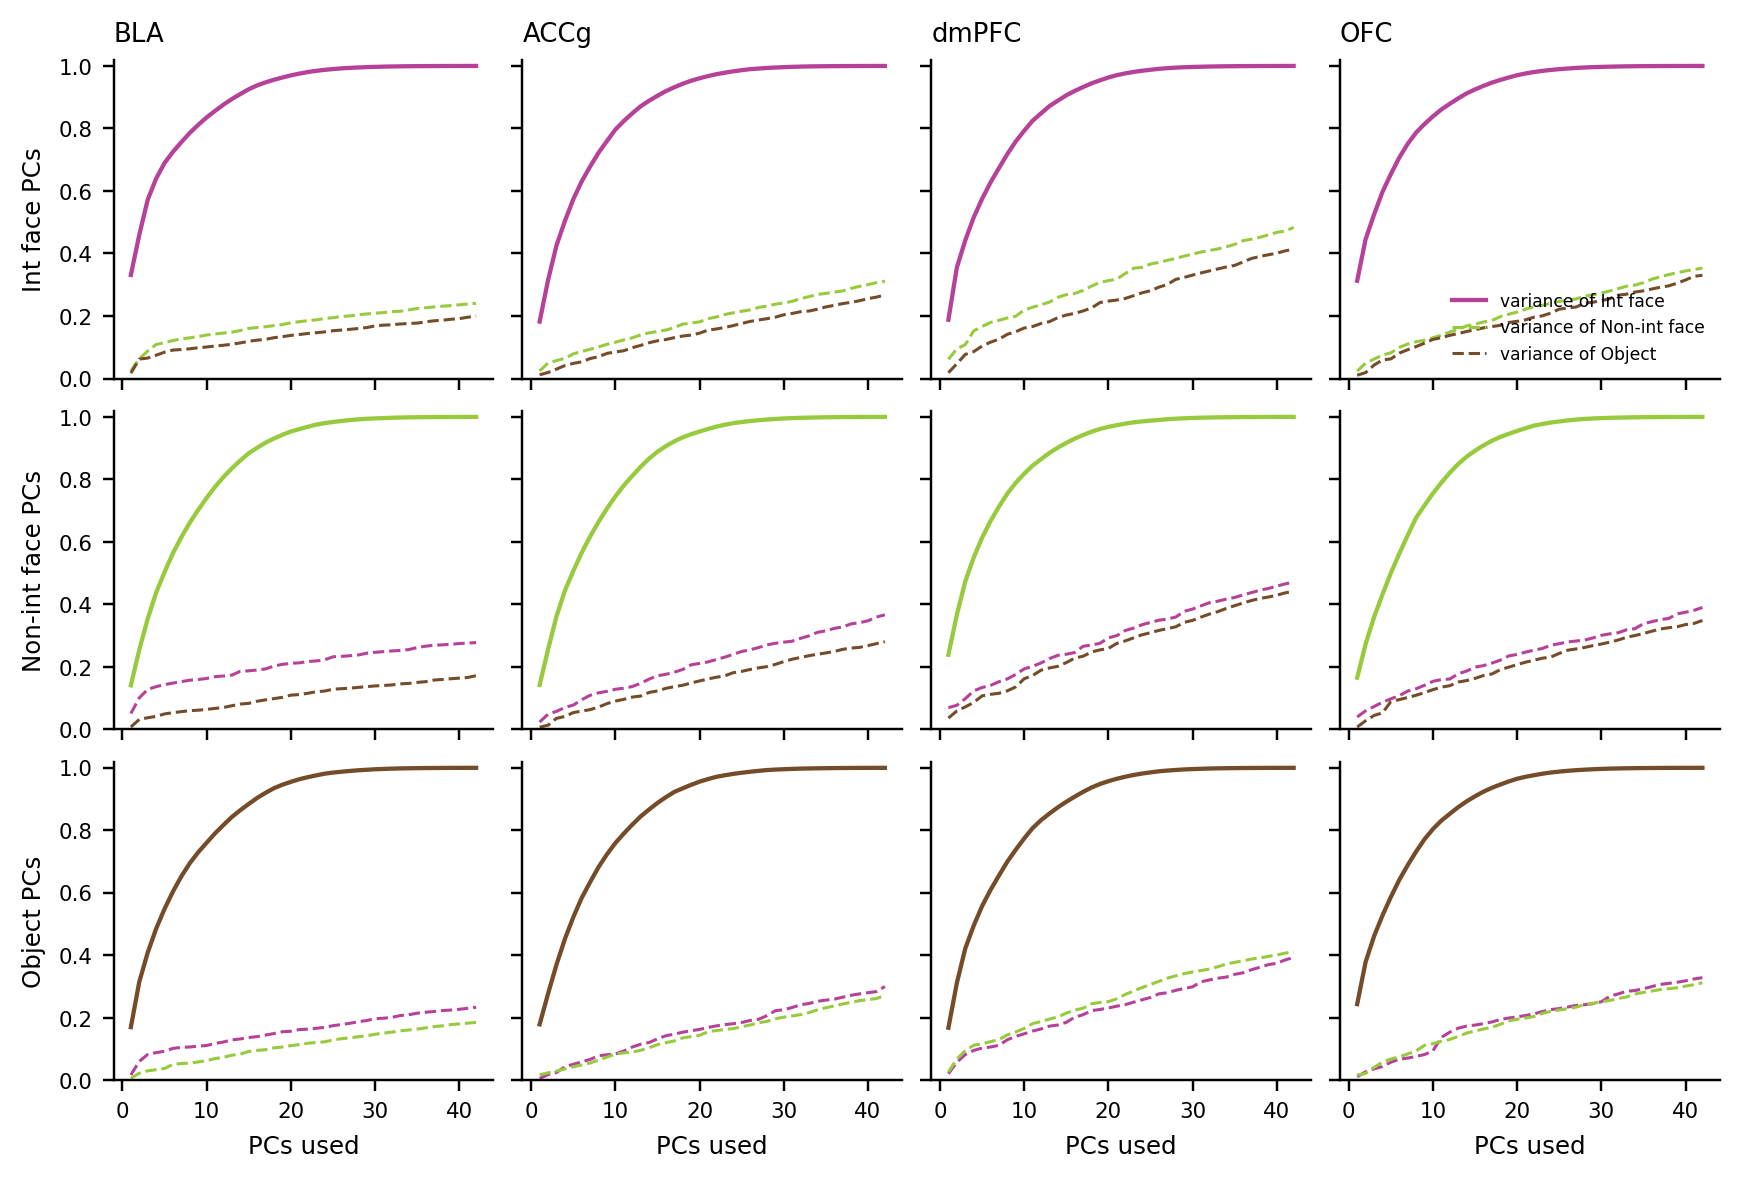

**Figure A1. Cross-condition variance explained.** Rows are the condition whose components are used, columns are regions, curves are the conditions being explained. The solid curve in each panel is the fitted condition explaining itself - the ceiling, by construction. Cross-condition curves plateau far below it in every region, so the conditions genuinely occupy different subspaces; and within each panel the two face conditions explain each other better than either explains object.

In [7]:
variance_curves = table(
    pd.concat(
        [
            pcs.cross_condition_variance_curve(population, fits[region], max_components=K)
            for region, population in populations.items()
        ],
        ignore_index=True,
    ),
    "t09_cross_condition_variance",
)
figure(
    viz.plot_cross_condition_variance_curves(variance_curves, layout="fit_rows"),
    "figA1_cross_condition_variance",
    "**Figure A1. Cross-condition variance explained.** Rows are the condition whose components are "
    "used, columns are regions, curves are the conditions being explained. The solid curve in each "
    "panel is the fitted condition explaining itself - the ceiling, by construction. Cross-condition "
    "curves plateau far below it in every region, so the conditions genuinely occupy different "
    "subspaces; and within each panel the two face conditions explain each other better than either "
    "explains object.",
)

### A.2 Alignment index and principal angles

The raw fraction has no reference: how much *could* any $k$-dimensional subspace
capture of $b$? At most $b$'s own top-$k$ eigenvalues. Normalising by that ceiling
gives the **alignment index**

$$A(a\to b) = \frac{\operatorname{tr}\left(V_a^{\top}C_bV_a\right)}{\sum_{j\le k}\lambda_j(C_b)} \in [0,1]$$

so $A = 1$ means $a$'s directions are as good for $b$ as $b$'s own best choice.

**A trap.** A randomly chosen $k$-dimensional subspace of an $N$-dimensional space
already captures a fraction $k/N$ by chance. These regions differ fourfold in
neuron count, so at $k = 42$ the chance floor runs from $42/537 = 0.08$ in BLA to
$42/187 = 0.22$ in dmPFC. Raw alignment indices are **not comparable across
regions**; the floor-corrected value $A^{\dagger} = (A - k/N)/(1 - k/N)$ is.

**Principal angles** are the scale-free counterpart. For orthonormal bases the
angles $\theta_1 \le \cdots \le \theta_k$ satisfy $\cos\theta_j = s_j(V_a^\top V_b)$,
the singular values of the overlap matrix: $\theta = 0$ is a shared direction,
$\theta = 90°$ an orthogonal one, and $\sum_j\cos^2\theta_j$ counts the effective
number of shared dimensions. They weight every direction equally, whereas $A$
weights by how much variance lies along each.

Intervals come from **subsampling neurons without replacement** (80%): drawing
with replacement duplicates neurons, and duplicated rows are perfectly correlated,
which lowers the covariance rank and inflates every overlap measure. Because
subsampling shifts these metrics systematically, intervals are reverse-percentile.

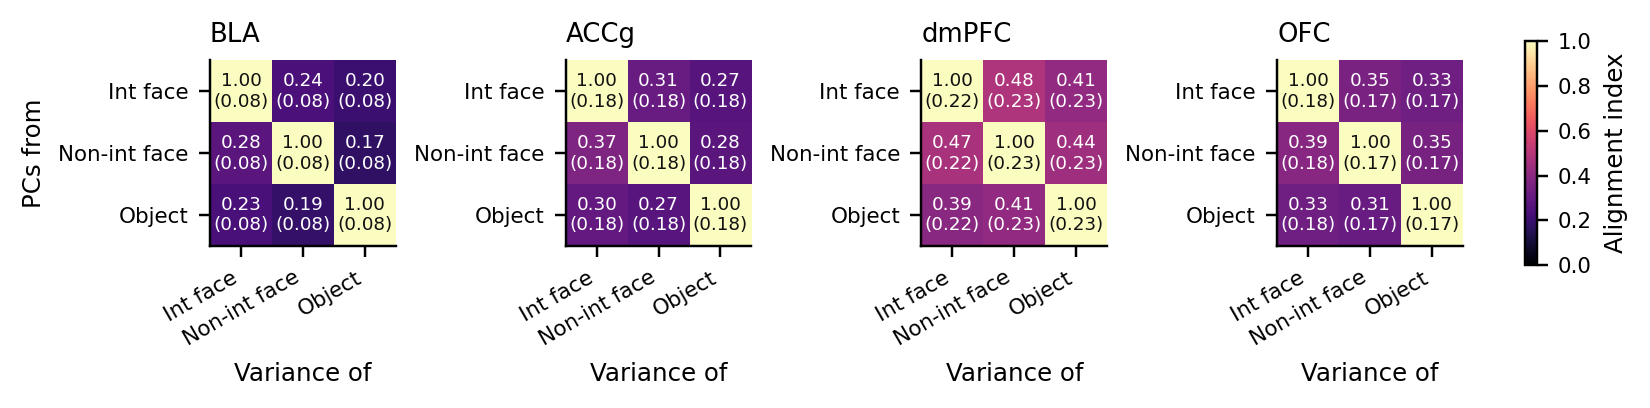

**Figure A2. Alignment index by region.** Rows are the condition supplying the components, columns the condition whose variance is evaluated; the value in brackets is the random-subspace chance floor for that region. The diagonal is 1 by construction. Note the floor differs markedly between regions, which is why the summary in Figure A4 uses the floor-corrected value.

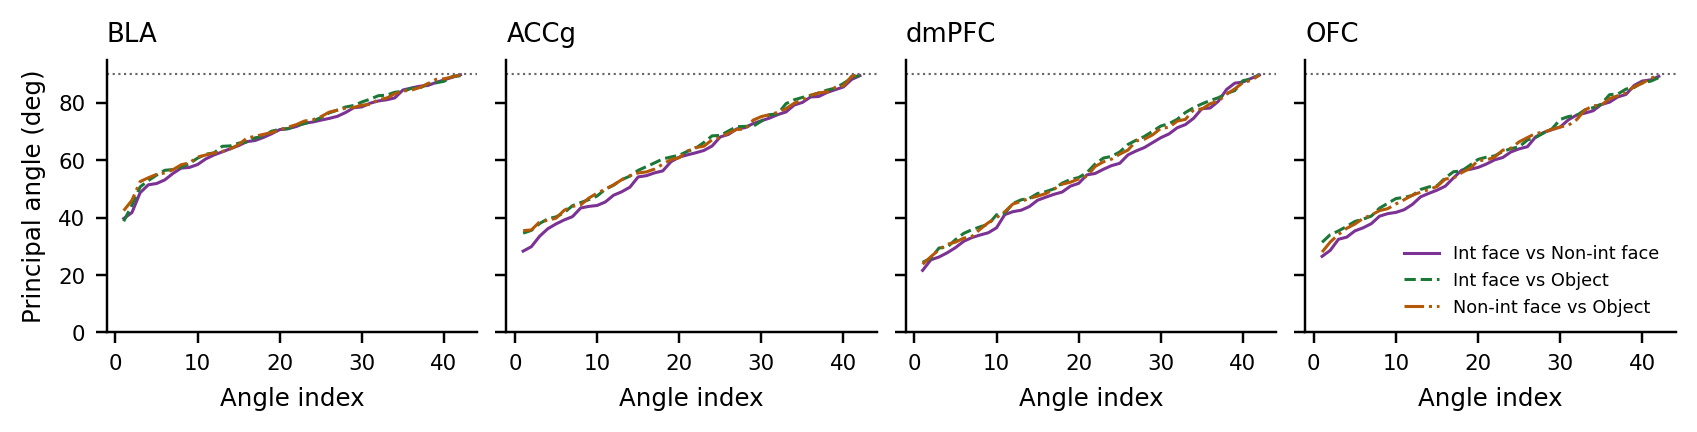

**Figure A3. Principal angle spectra.** Sorted angles between each pair of condition subspaces, per region. A pair hugging 0 degrees shares a subspace; one rising steeply occupies different leading directions. Plotting the whole spectrum rather than its mean shows how many dimensions the conditions differ in - here the angles rise immediately, so they differ from the first dimension onward rather than only in the tail.

In [8]:
figure(
    viz.plot_alignment_matrix(subspace_table := table(
        pcs.build_region_subspace_summary(
            populations, fits, n_components=K, n_null_subspaces=200, seed=RANDOM_SEED
        ),
        "t10_subspace_metrics",
    )),
    "figA2_alignment_matrix",
    "**Figure A2. Alignment index by region.** Rows are the condition supplying the components, "
    "columns the condition whose variance is evaluated; the value in brackets is the random-subspace "
    "chance floor for that region. The diagonal is 1 by construction. Note the floor differs "
    "markedly between regions, which is why the summary in Figure A4 uses the floor-corrected value.",
)
figure(
    viz.plot_principal_angle_spectra(fits, n_components=K),
    "figA3_principal_angles",
    "**Figure A3. Principal angle spectra.** Sorted angles between each pair of condition subspaces, "
    "per region. A pair hugging 0 degrees shares a subspace; one rising steeply occupies different "
    "leading directions. Plotting the whole spectrum rather than its mean shows how many dimensions "
    "the conditions differ in - here the angles rise immediately, so they differ from the first "
    "dimension onward rather than only in the tail.",
)

### A.3 Summary, with statistics

Collapsing A1–A3 to one number per region and pair, with resampling intervals and
FDR-corrected contrasts. This is the panel that should be read alongside Figure 5:
subspace overlap **does** rank the two face conditions closest, consistently, but
by a small margin — and it does not produce the categorical face/object split that
time-locked co-movement does.

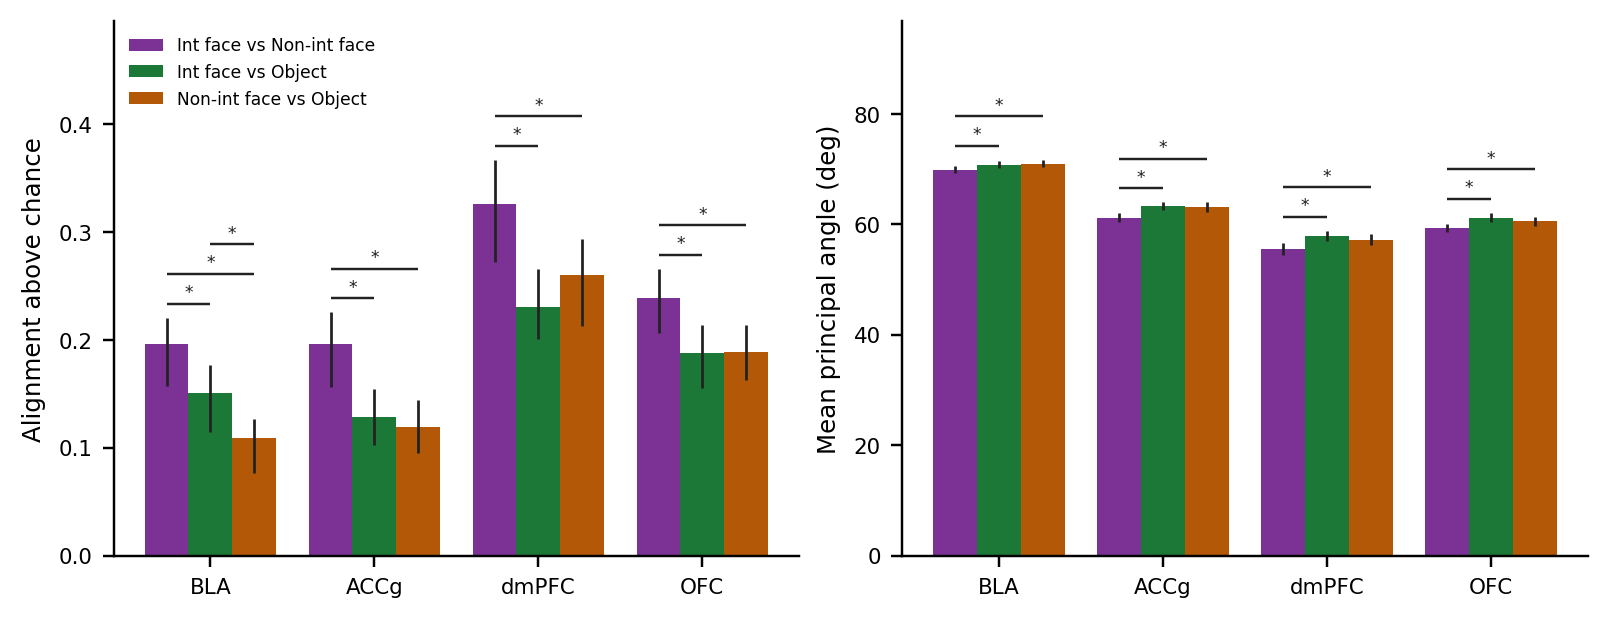

**Figure A4. Subspace overlap and separation, summarised.** *Left*: alignment index above the k/N chance floor, so 0 is chance and the four regions are comparable. *Right*: mean principal angle between the two condition subspaces. Vertical lines are 95% reverse-percentile intervals from neuron subsampling; brackets are FDR-corrected contrasts (* p < 0.05). The two face conditions are the most aligned pair in every region, significantly so, but the margin is small and the two face-object pairs are usually indistinguishable from each other.

- The face pair is the most-aligned pair in **4 of 4** regions.
- It exceeds the other two significantly in **8 of 8** region x comparison cases after FDR correction.
- But it leads the next-best pair by only **0.057** on average (range 0.046-0.067) on a scale where 0 is chance and 1 a perfect match.

So subspace overlap and time-locked co-movement agree on the *ordering* of the pairs but disagree sharply on the *size* of the effect. The dissociation is the point: face and object conditions have comparable access to similar directions of population activity, and differ in whether a common process drives them along those directions at the same moments.

In [9]:
subspace_effects, subspace_contrasts = pcs.bootstrap_subspace_metrics(
    populations, n_components=K, n_bootstrap=N_SUBSAMPLES, seed=RANDOM_SEED
)
table(subspace_effects, "t11_subspace_effects")
table(subspace_contrasts, "t12_subspace_contrasts")
figure(
    viz.plot_subspace_metric_summary(subspace_effects, subspace_contrasts),
    "figA4_subspace_summary",
    "**Figure A4. Subspace overlap and separation, summarised.** *Left*: alignment index above the "
    "k/N chance floor, so 0 is chance and the four regions are comparable. *Right*: mean principal "
    "angle between the two condition subspaces. Vertical lines are 95% reverse-percentile intervals "
    "from neuron subsampling; brackets are FDR-corrected contrasts (* p < 0.05). The two face "
    "conditions are the most aligned pair in every region, significantly so, but the margin is small "
    "and the two face-object pairs are usually indistinguishable from each other.",
)

alignment = subspace_effects[subspace_effects["metric"] == "alignment_above_floor"]
winners = alignment.loc[alignment.groupby("region")["value"].idxmax()].set_index("region")["pair_label"]
margins = []
for region in sorted(populations):
    values = alignment[alignment["region"] == region].set_index("pair_label")["value"]
    margins.append(
        float(values["face_interactive__vs__face_non_interactive"]
              - values.drop("face_interactive__vs__face_non_interactive").max())
    )
significant = subspace_contrasts[
    (subspace_contrasts["metric"] == "alignment_above_floor")
    & (subspace_contrasts["pair_a"] == "face_interactive__vs__face_non_interactive")
    & (subspace_contrasts["p_value_corrected"] < 0.05)
]
lines([
    f"- The face pair is the most-aligned pair in "
    f"**{int((winners == 'face_interactive__vs__face_non_interactive').sum())} of {len(winners)}** regions.",
    f"- It exceeds the other two significantly in **{len(significant)} of {2 * len(populations)}** "
    "region x comparison cases after FDR correction.",
    f"- But it leads the next-best pair by only **{np.mean(margins):.3f}** on average "
    f"(range {min(margins):.3f}-{max(margins):.3f}) on a scale where 0 is chance and 1 a perfect match.",
    "",
    "So subspace overlap and time-locked co-movement agree on the *ordering* of the pairs but "
    "disagree sharply on the *size* of the effect. The dissociation is the point: face and object "
    "conditions have comparable access to similar directions of population activity, and differ in "
    "whether a common process drives them along those directions at the same moments.",
])

### A.4 Controls

Three checks on the main results, reported in full in the long-form notebook.

**Is the geometry more than chance?** A condition-label shuffle permutes which of a
neuron's three traces is called which, independently per neuron, so every neuron
keeps all its real data and only the population's agreement about condition
identity is destroyed. This null points the opposite way to intuition: a shuffled
population has subspaces that are, if anything, *more* dissimilar, because the
real conditions share a large common fixation-locked response. What it tests is
whether the observed **shared** structure is real.

**Does it replicate?** Splitting the neurons into two disjoint halves and rerunning
the pipeline in each tests whether the geometry survives a change of sample.

**Is it the trial-count imbalance?** Every quantity describing how much a condition
varies is corrected using the stored SEMs, as described in §2.1.

In [10]:
reliability = table(
    pcs.summarize_split_half_reliability(
        pd.concat(
            [
                pcs.split_half_geometry_reliability(
                    population, n_components=K, n_splits=50, seed=RANDOM_SEED
                )
                for population in populations.values()
            ],
            ignore_index=True,
        )
    ),
    "t13_split_half_reliability",
)
dynamics_summary = table(
    pd.concat(
        [
            pcs.condition_dynamics_summary(population, fits[region]["concatenated"], n_components=K)
            for region, population in populations.items()
        ],
        ignore_index=True,
    ),
    "t14_condition_dynamics",
)
display(Markdown("**Split-half reliability of the condition geometry**"))
display(reliability[[
    "region", "split_half_distance_correlation", "closest_pair_agreement",
    "modal_closest_pair", "modal_closest_pair_frequency",
]].round(3))
lines([
    "",
    "Distances measured in one half of the neurons predict the other half at r = "
    f"{reliability['split_half_distance_correlation'].min():.2f}-"
    f"{reliability['split_half_distance_correlation'].max():.2f}, and the two halves agree on which "
    "pair is closest on "
    f"{reliability['closest_pair_agreement'].min():.0%}-{reliability['closest_pair_agreement'].max():.0%} "
    "of splits (chance 33%). Agreement is high in BLA, ACCg and OFC and poor in dmPFC, which is "
    "consistent with dmPFC differing throughout.",
    "",
    "**Trial-count correction.** After removing the SEM-derived noise energy, the interactive-face "
    f"state remains the most compact in "
    f"{sum(1 for r in sorted(populations) if dynamics_summary[dynamics_summary['region'] == r].set_index('condition')['excursion_rms_corrected'].idxmin() == 'face_interactive')}"
    f" of {len(populations)} regions and the lowest-dimensional in "
    f"{sum(1 for r in sorted(populations) if dynamics_summary[dynamics_summary['region'] == r].set_index('condition')['dynamics_participation_ratio_corrected'].idxmin() == 'face_interactive')}"
    f" of {len(populations)}, so its compactness is not an artefact of its fivefold trial advantage. "
    "Bin-to-bin speed, by contrast, is barely resolvable: the ratio of measured step energy to "
    "the energy noise alone would produce has a median of "
    f"{dynamics_summary['speed_over_noise'].median():.1f} "
    f"(range {dynamics_summary['speed_over_noise'].min():.1f}-{dynamics_summary['speed_over_noise'].max():.1f}), "
    "so most of the moment-to-moment motion in these averages is estimation noise. Speed is not "
    "interpreted anywhere in this chapter.",
])

display(Markdown("---\n**Figures and tables written to:**"))
lines([f"- `{name}`" for name in sorted(FIGURE_MANIFEST)])
print(FIGURE_DIR)

**Split-half reliability of the condition geometry**

,region,split_half_distance_correlation,closest_pair_agreement,modal_closest_pair,modal_closest_pair_frequency
0,accg,0.874,0.90,face_interactive__vs__face_non_interactive,0.95
1,bla,0.829,0.92,face_interactive__vs__face_non_interactive,0.96
2,dmpfc,0.480,0.30,face_interactive__vs__object,0.65
3,ofc,0.827,1.00,face_interactive__vs__face_non_interactive,1.00



Distances measured in one half of the neurons predict the other half at r = 0.48-0.87, and the two halves agree on which pair is closest on 30%-100% of splits (chance 33%). Agreement is high in BLA, ACCg and OFC and poor in dmPFC, which is consistent with dmPFC differing throughout.

**Trial-count correction.** After removing the SEM-derived noise energy, the interactive-face state remains the most compact in 4 of 4 regions and the lowest-dimensional in 4 of 4, so its compactness is not an artefact of its fivefold trial advantage. Bin-to-bin speed, by contrast, is barely resolvable: the ratio of measured step energy to the energy noise alone would produce has a median of 1.4 (range 0.6-3.6), so most of the moment-to-moment motion in these averages is estimation noise. Speed is not interpreted anywhere in this chapter.

---
**Figures and tables written to:**

- `fig01_variance_decomposition.pdf`
- `fig01_variance_decomposition.png`
- `fig02_dimensionality.pdf`
- `fig02_dimensionality.png`
- `fig03_trajectories_3d.pdf`
- `fig03_trajectories_3d.png`
- `fig04_pc_condition_separation.pdf`
- `fig04_pc_condition_separation.png`
- `fig05_comovement.pdf`
- `fig05_comovement.png`
- `figA1_cross_condition_variance.pdf`
- `figA1_cross_condition_variance.png`
- `figA2_alignment_matrix.pdf`
- `figA2_alignment_matrix.png`
- `figA3_principal_angles.pdf`
- `figA3_principal_angles.png`
- `figA4_subspace_summary.pdf`
- `figA4_subspace_summary.png`
- `t01_inventory.csv`
- `t02_variance_shares.csv`
- `t03_variance_share_contrasts.csv`
- `t04_dimensionality.csv`
- `t05_pc_separation.csv`
- `t06_pc_separation_contrasts.csv`
- `t07_offset_vs_dynamics.csv`
- `t08_shift_test.csv`
- `t09_cross_condition_variance.csv`
- `t10_subspace_metrics.csv`
- `t11_subspace_effects.csv`
- `t12_subspace_contrasts.csv`
- `t13_split_half_reliability.csv`
- `t14_condition_dynamics.csv`

/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_population_pc_subspace/main_chapter
